In [2]:
import torch

# Check if CUDA is available
cuda_available = torch.cuda.is_available()
print(f"CUDA available: {cuda_available}")

if cuda_available:
    # Get the number of GPUs available
    num_gpus = torch.cuda.device_count()
    print(f"Number of GPUs available: {num_gpus}")

    # Get the name of each GPU
    for i in range(num_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        print(f"GPU {i}: {gpu_name}")

    # Get the current GPU memory usage
    for i in range(num_gpus):
        gpu_memory_allocated = torch.cuda.memory_allocated(i)
        gpu_memory_reserved = torch.cuda.memory_reserved(i)
        print(f"GPU {i} memory allocated: {gpu_memory_allocated / (1024 ** 3):.2f} GB")
        print(f"GPU {i} memory reserved: {gpu_memory_reserved / (1024 ** 3):.2f} GB")
else:
    print("CUDA is not available.")

CUDA available: True
Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4060 Laptop GPU
GPU 0 memory allocated: 0.02 GB
GPU 0 memory reserved: 0.05 GB


In [3]:
import sys
import os
import pickle
import logging
import numba
import matplotlib
import matplotlib.pyplot as plt
logging.getLogger('matplotlib.font_manager').disabled = True
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

matplotlib_logger = logging.getLogger('matplotlib')
matplotlib_logger.setLevel(logging.WARNING)

# Add the src directory to sys.path
src_path = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(src_path)

from src.IndependentSteps import Pycromanager2NativeDataType, FFF2NativeDataType, Make_Output_Dir_JF, Make_Analysis_Dir_JF, \
                                    ConsolidateImageShapes, TrimZSlices, AutomaticSpotDetection_JF

from src.SequentialSteps import CellSegmentationStepClass_JF, BIGFISH_SpotDetection, SimpleCellposeSegmentaion

from src.FinalizationSteps import BuildPDFReport, SaveSpotDetectionResults, SaveMasksToAnalysis, SendAnalysisToNAS

from src.Parameters import Parameters, Experiment, Settings, ScopeClass, DataContainer

from src.GeneralOutput import OutputClass

from src.Displays import Display

from src.GUI import GUI, StepGUI

from src.Pipeline import Pipeline

DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7
DEBUG:h5py._conv:Creating converter from 7 to 5
DEBUG:h5py._conv:Creating converter from 5 to 7


# This code isn't compete, I need your help

In [ ]:
StepGUI().create_gui(BIGFISH_SpotDetection())


# Parameters
initalization

In [4]:
scope = ScopeClass()
data = DataContainer()
settings = Settings(num_chunks_to_run=2, load_in_mask=True)
experiment = Experiment(initial_data_location=r'smFISH_images\Eric_smFISH_images\20230511\DUSP1_DexTimeConcSweep_10nM_75min_041223')




Individuals

In [5]:
experiment.todict()

{'initial_data_location': 'smFISH_images\\Eric_smFISH_images\\20230511\\DUSP1_DexTimeConcSweep_10nM_75min_041223',
 'index_dict': None,
 'nucChannel': None,
 'cytoChannel': None,
 'FISHChannel': None,
 'voxel_size_z': 300,
 'independent_params': None,
 'kwargs': None,
 'timestep_s': None}

In [6]:
experiment.nucChannel = 2
experiment.cytoChannel = 1

In [7]:
experiment.todict()

{'initial_data_location': 'smFISH_images\\Eric_smFISH_images\\20230511\\DUSP1_DexTimeConcSweep_10nM_75min_041223',
 'index_dict': None,
 'nucChannel': 2,
 'cytoChannel': 1,
 'FISHChannel': None,
 'voxel_size_z': 300,
 'independent_params': None,
 'kwargs': None,
 'timestep_s': None}

All Params

In [8]:
Parameters._instances

[ScopeClass(voxel_size_yx=130, spot_z=500, spot_yx=360, microscope_saving_format='pycromanager'),
 DataContainer(local_dataset_location=None, total_num_chunks=None, images=None, masks=None),
 Settings(return_data_to_NAS=True, NUMBER_OF_CORES=4, save_files=True, num_chunks_to_run=2, download_data_from_NAS=True, connection_config_location='c:\\Users\\Jack\\Documents\\GitHub\\FISH_Processing\\config_nas.yml', share_name='share', display_plots=True, load_in_mask=True),
 Experiment(index_dict=None, nucChannel=2, cytoChannel=1, FISHChannel=None, voxel_size_z=300, independent_params=None, kwargs=None, timestep_s=None)]

In [9]:
Parameters.get_parameters()

{'voxel_size_yx': 130,
 'spot_z': 500,
 'spot_yx': 360,
 'microscope_saving_format': 'pycromanager',
 'local_dataset_location': None,
 'total_num_chunks': None,
 'images': None,
 'masks': None,
 'return_data_to_NAS': True,
 'NUMBER_OF_CORES': 4,
 'save_files': True,
 'num_chunks_to_run': 2,
 'download_data_from_NAS': True,
 'connection_config_location': 'c:\\Users\\Jack\\Documents\\GitHub\\FISH_Processing\\config_nas.yml',
 'share_name': 'share',
 'display_plots': True,
 'load_in_mask': True,
 'initial_data_location': 'smFISH_images\\Eric_smFISH_images\\20230511\\DUSP1_DexTimeConcSweep_10nM_75min_041223',
 'index_dict': None,
 'nucChannel': 2,
 'cytoChannel': 1,
 'FISHChannel': None,
 'voxel_size_z': 300,
 'independent_params': None,
 'kwargs': None,
 'timestep_s': None}

Validate 

In [10]:
Parameters.validate()

FISHChannel not set


In [11]:
experiment.FISHChannel = 0

In [12]:
Parameters.validate()

# Load in data

In [14]:
FFF2NativeDataType().run()

In [15]:
data.todict()

{'local_dataset_location': 'DUSP1_DexTimeConcSweep_10nM_75min_041223\\DUSP1_DexTimeConcSweep_10nM_75min_041223.h5',
 'total_num_chunks': 30,
 'images': dask.array<rechunk-merge, shape=(30, 1, 3, 27, 896, 600), dtype=float32, chunksize=(1, 1, 3, 27, 896, 600), chunktype=numpy.ndarray>,
 'masks': dask.array<rechunk-merge, shape=(30, 1, 3, 1, 896, 600), dtype=float32, chunksize=(1, 1, 3, 1, 896, 600), chunktype=numpy.ndarray>}

chunks

In [16]:
data.images

dask.array<rechunk-merge, shape=(30, 1, 3, 27, 896, 600), dtype=float32, chunksize=(1, 1, 3, 27, 896, 600), chunktype=numpy.ndarray>

# Creating a step

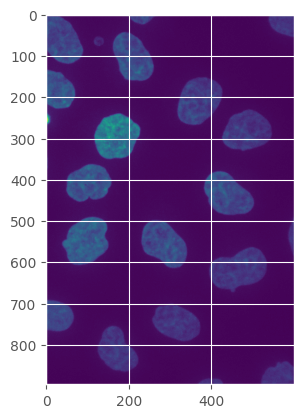

dask.array<max-aggregate, shape=(896, 600), dtype=float32, chunksize=(896, 600), chunktype=numpy.ndarray>

In [28]:
Display().displayImage_maxProject(0, 0, experiment.nucChannel)

In [ ]:
import cellpose
from cellpose import models, train
import numpy as np
import dask.array as da


model = models.CellposeModel(gpu=True, model_type='nuclei', pretrained_model=r"C:\Users\Jack\Documents\GitHub\FISH_Processing\models\GAPDH_cyto")

image = da.max(data.images[0, 0, experiment.nucChannel, :, :, :], axis=0)

image

INFO:cellpose.models:>> nuclei << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models\nucleitorch_0
INFO:cellpose.models:>>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)


In [26]:
nuc_mask, flows, styles = model.eval(image, diameter=180, channels=[0, 0])

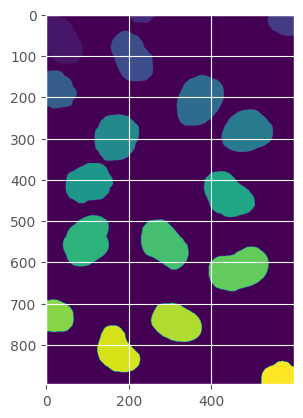

In [27]:
plt.imshow(nuc_mask)

# Run Processing Steps

Cell Segmentation

In [ ]:
settings.cellpose_min_size = 500
settings.cellpose_diameter = 180
settings.cellpose_pretrained_model = r"C:\Users\Jack\Documents\GitHub\FISH_Processing\models\GAPDH_cyto"

INFO:cellpose.models:>> nuclei << model set to be used


++++++++++++++++++++++++++++
Running :  SimpleCellposeSegmentaion
++++++++++++++++++++++++++++

 ###################### 
FOV:0 TIMEPOINT: 0
 ###################### 


INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models\nucleitorch_0
INFO:cellpose.models:>>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>> nuclei << model set to be used
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models\nucleitorch_0
INFO:cellpose.models:>>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:channels set to [2, 0]
INFO:cellpose.models:~~~ FINDING MASKS ~~~
INFO:cellpose.models:>>>> TOTAL TIME 1.57 sec
INFO:cellpose.models:>> cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models

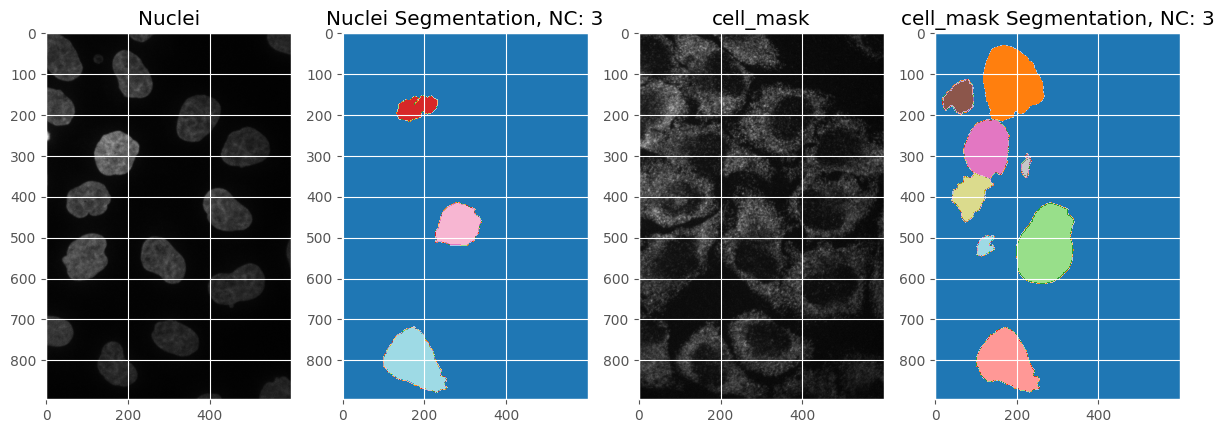

INFO:cellpose.models:>> nuclei << model set to be used


Overwriting masks in DataContainer
 ###################### 
FOV:1 TIMEPOINT: 0
 ###################### 


INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models\nucleitorch_0
INFO:cellpose.models:>>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>> nuclei << model set to be used
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models\nucleitorch_0
INFO:cellpose.models:>>>> model diam_mean =  17.000 (ROIs rescaled to this size during training)
INFO:cellpose.models:channels set to [2, 0]
INFO:cellpose.models:~~~ FINDING MASKS ~~~
INFO:cellpose.models:>>>> TOTAL TIME 1.60 sec
INFO:cellpose.models:>> cyto3 << model set to be used
INFO:cellpose.core:** TORCH CUDA version installed and working. **
INFO:cellpose.core:>>>> using GPU (CUDA)
INFO:cellpose.models:>>>> loading model C:\Users\Jack\.cellpose\models

In [ ]:
SimpleCellposeSegmentaion().run()

In [ ]:
cellSegmentation = OutputClass.get_all_instances()[0]
cellSegmentation

In [ ]:
Display().displayImage_maxProject(5, 0, channel=experiment.nucChannel)
Display().displayMask(5, 0, channel=experiment.nucChannel)

Spot Detection

In [ ]:
BIGFISH_SpotDetection().run()

Outputs

In [ ]:
spotDetection = OutputClass.get_all_instances()[0]
spotDetection

In [ ]:
vars(spotDetection)

In [ ]:
OutputClass.clear_instances()

# GUIs

In [ ]:
StepGUI().create_gui(SimpleCellposeSegmentaion())

In [ ]:
StepGUI().create_gui(BIGFISH_SpotDetection())


In [ ]:
OutputClass.clear_instances()

# Train Cellpose Model

In [ ]:
import cellpose
from cellpose import models, train

# testing training data split
test = data.images[20:, 0].squeeze()
images = data.images[:20, 0].squeeze()

mask_test = data.masks[20:, 0].squeeze()
mask_train = data.masks[:20, 0].squeeze()

# convert these to list of np arrays
images = [images[p, :, :, :, :] for p in range(images.shape[0])]
test = [test[p, :, :, :, :] for p in range(test.shape[0])]
mask_train = [mask_train[p, :, :, :] for p in range(mask_train.shape[0])]
mask_test = [mask_test[p, :, :, :] for p in range(mask_test.shape[0])]

# seperate into nuc and cyto
nuc_images = [im[experiment.nucChannel, :, :, :] for im in images]
cyto_images = [im[experiment.cytoChannel, :, :, :] for im in images]

nuc_test = [im[experiment.nucChannel, :, :, :] for im in test]
cyto_test = [im[experiment.cytoChannel, :, :, :] for im in test]

nuc_mask_train = [im[experiment.nucChannel, :, :] for im in mask_train]
cyto_mask_train = [im[experiment.cytoChannel, :, :] for im in mask_train]

nuc_mask_test = [im[experiment.nucChannel, :, :] for im in mask_test]
cyto_mask_test = [im[experiment.cytoChannel, :, :] for im in mask_test]

# max project to 2D
nuc_images = [im.max(axis=0).compute() for im in nuc_images]
cyto_images = [im.max(axis=0).compute() for im in cyto_images]

nuc_test = [im.max(axis=0).compute() for im in nuc_test]
cyto_test = [im.max(axis=0).compute() for im in cyto_test]

# train nuc model
model_name = "cyto_gapdh"
model_path = os.path.join('temp_models', model_name)
# os.mkdir('temp_models')




In [ ]:
# P


# Creating Pipelines

In [ ]:
pipeline = Pipeline()



In [ ]:
pipeline.execute_independent_steps()

In [ ]:
pipeline.execute_sequential_steps()

In [ ]:
pipeline.execute_sequential_steps()

# Running Multiple Pipelines Together

# Running on Clusters